# Car Price Analysis Project
## Machine Learning Assignment 1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/car_price.csv")
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017.0,12500.0,Manual,15735.0,Petrol,150.0,55.4,1.4,audi
1,A6,2016.0,16500.0,Automatic,36203.0,Diesel,20.0,64.2,2.0,audi
2,A1,2016.0,11000.0,Manual,29946.0,Petrol,30.0,55.4,1.4,audi
3,A4,2017.0,16800.0,Automatic,25952.0,Diesel,145.0,67.3,2.0,audi
4,A3,2019.0,17300.0,Manual,1998.0,Petrol,145.0,49.6,1.0,audi


# Task 1: Exploratory Data Analysis

In [2]:
# shape of dataset (How many rows and columns does the dataset have?)

df.shape

(72435, 10)

In [12]:
#  Data Types and

df.dtypes

model            object
year            float64
price           float64
transmission     object
mileage         float64
fuelType         object
tax             float64
mpg             float64
engineSize      float64
Make             object
dtype: object

In [13]:
#  Feature Classification (Which features are numerical? Which are categorical? )

num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns
print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical Columns: Index(['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize'], dtype='object')
Categorical Columns: Index(['model', 'transmission', 'fuelType', 'Make'], dtype='object')


In [4]:
#Missing Values (Are there any missing values? How many, and in which columns?)

df.isnull().sum()

model           3621
year            3622
price           3621
transmission    3623
mileage         3622
fuelType        3622
tax             3621
mpg             3621
engineSize      3622
Make            3621
dtype: int64

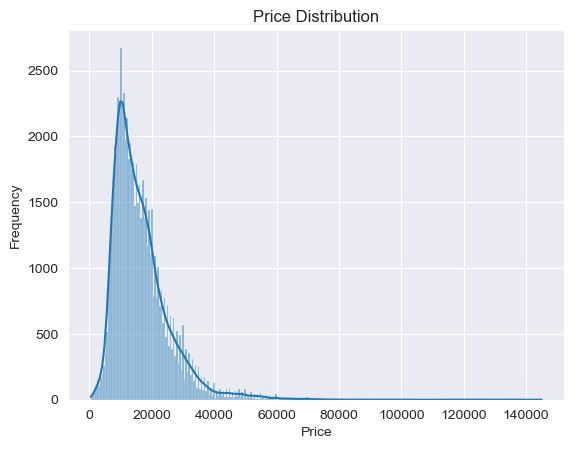

count     68814.000000
mean      16583.919261
std        9304.412707
min         495.000000
25%       10167.250000
50%       14495.000000
75%       20359.750000
max      145000.000000
Name: price, dtype: float64


In [6]:
#Price Distribution ( What does the distribution of car prices look like? )

sns.histplot(df['price'], kde=True)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

print(df['price'].describe())

The distribution is right-skewed, meaning most cars are low-priced with few expensive ones

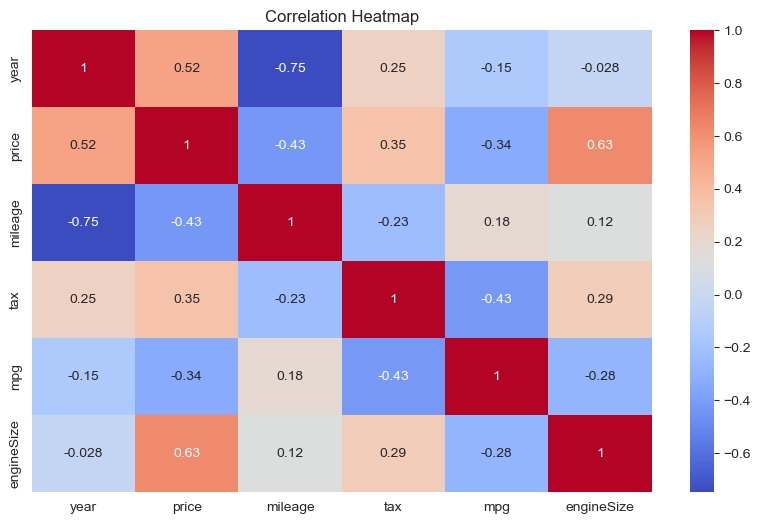

In [7]:
# Correlation Between Features (Which features seem most related to price? )

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [14]:
corr['price'].sort_values(ascending=False)

price         1.000000
engineSize    0.629839
year          0.519383
tax           0.353204
mpg          -0.335615
mileage      -0.427524
Name: price, dtype: float64

The most positively correlated features are: engineSize, year

The most negatively correlated features are: mileage, mpg

 ### Relationship Between Price and Important Features

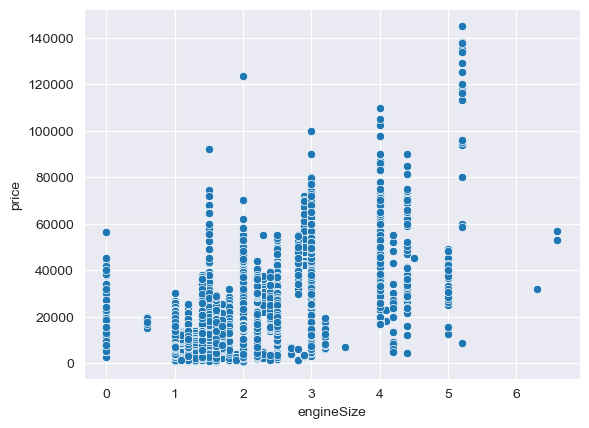

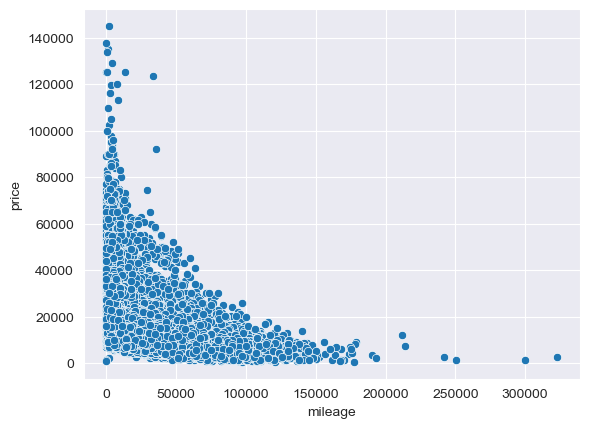

In [15]:
# numerical (most related)
sns.scatterplot(x=df['engineSize'], y=df['price'])
plt.show()

sns.scatterplot(x=df['mileage'], y=df['price'])
plt.show()

In [19]:
#categorical
print(df.groupby('model')['price'].mean().sort_values(ascending=False))
print("------------")
print(df.groupby('Make')['price'].mean().sort_values(ascending=False))
print("------------")
print(df.groupby('fuelType')['price'].mean().sort_values(ascending=False))
print("------------")
print(df.groupby('transmission')['price'].mean().sort_values(ascending=False))

model
R8            97257.080000
X7            69878.187500
8 Series      64424.875000
Q8            59598.133333
California    57565.500000
                  ...     
Getz           1927.500000
Streetka       1924.500000
Amica          1750.000000
Fox            1733.500000
Accent         1295.000000
Name: price, Length: 145, dtype: float64
------------
Make
audi       22894.679872
BMW        22727.820273
vw         16837.325011
skoda      14292.749382
Hyundai    12806.737070
toyota     12504.774279
Ford       12279.505885
Name: price, dtype: float64
------------
fuelType
Hybrid      19067.922073
Diesel      18885.788116
Other       17414.302885
Electric    17374.600000
Petrol      14743.939671
Name: price, dtype: float64
------------
transmission
Semi-Auto    23493.355456
Automatic    21373.580206
Other        14571.000000
Manual       12543.124548
Name: price, dtype: float64


Based on the analysis of both categorical features (groupby mean) and numerical features (correlation matrix), we can conclude the following :

engineSize (strong positive correlation: 0.63)

year (moderate positive correlation: 0.52)

mileage (moderate negative correlation: -0.43)

model (very strong variation in average price across different car models)

transmission (large differences in average price across categories)

Make (strong variation in average price between brands)


 Overall, engineSize,model, transmission, and Make show the strongest relationship with price, followed by year and mileage.

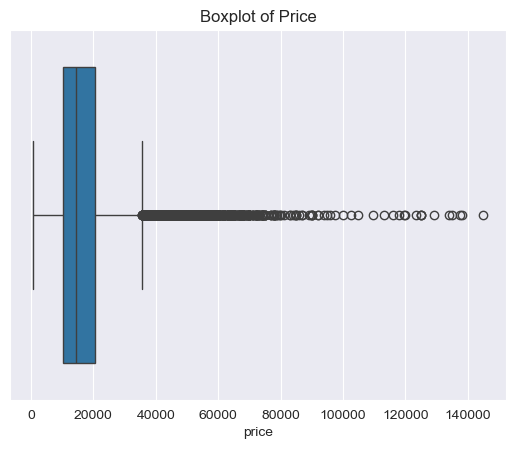

In [18]:
#Outlier Detection

sns.boxplot(x=df['price'])
plt.title("Boxplot of Price")
plt.show()

# Task 2 : Data Preprocessing

**step 1 : Handling missing values**
1. Drop Row:
 - Price is the target variable , we can't have a row without price
  - Model has too many unique values to be a useful feature
2. Fill Nulls with:
 - Median: Mileage & Engine Size because median can't be affected by outliers
  - Mode: Categorical features : Fuel Type, Transmission and Condition

In [132]:
df_clean = df.copy()

df_clean.dropna(subset=['Price'], inplace = True)
df_clean.dropna(subset=['Model'], inplace=True)

df_clean['Engine Size'] = df_clean['Engine Size'].fillna(df_clean['Engine Size'].median())
df_clean['Mileage'] = df_clean['Mileage'].fillna(df_clean['Mileage'].median())

df_clean['Fuel Type'] = df_clean['Fuel Type'].fillna(df_clean['Fuel Type'].mode()[0])
df_clean['Transmission'] = df_clean['Transmission'].fillna(df_clean['Transmission'].mode()[0])
df_clean['Condition'] = df_clean['Condition'].fillna(df_clean['Condition'].mode()[0])

df_clean.isnull().sum()

Car ID          0
Brand           0
Year            0
Engine Size     0
Fuel Type       0
Transmission    0
Mileage         0
Condition       0
Price           0
Model           0
dtype: int64

In [133]:
df_clean.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832.0,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,148940.0,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601.0,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682.0,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,148940.0,Like New,73577.10,Mustang


**step 2 : Detect and handle outliers**

In [134]:
numerical_cols = ['Year', 'Engine Size', 'Mileage']

for col in numerical_cols:
    Q1  = df_clean[col].quantile(0.25)
    Q3  = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    outliers = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)]

    print(f'{col}: {len(outliers)} , outliers : bounds [{lower:.2f}, {upper:.2f}]')

    df_clean[col] = df_clean[col].clip(lower=lower , upper= upper)

Year: 0 , outliers : bounds [1988.00, 2036.00]
Engine Size: 0 , outliers : bounds [-1.15, 8.05]
Mileage: 0 , outliers : bounds [-137118.00, 433370.00]


No significant outliers detected after IQR analysis. Winsorization was applied as a safety step but had no effect on the data.

**step 3 : Encoding Categorical columns**

In [135]:
cat_cols_to_encode = ['Transmission', 'Brand', 'Fuel Type', 'Condition']

for col in cat_cols_to_encode:
    print(f"{col}: {df_clean[col].nunique()}")

Transmission: 2
Brand: 7
Fuel Type: 4
Condition: 3


**Label Encoding : Transmission**

Transmission has only 2 values (Manual & Automatic), so we use label encoding

In [136]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

le = LabelEncoder()
df_clean['Transmission'] = le.fit_transform(df_clean['Transmission'])


**One-Hot Encoding : Brand, Fuel Type, Condition**

These columns have no numeric order, so we create a separate binary column for each unique value

In [137]:
ohe_cols = ['Brand', 'Fuel Type', 'Condition']
enc      = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

ohe_array        = enc.fit_transform(df_clean[ohe_cols])
ohe_feature_names = enc.get_feature_names_out(ohe_cols)
ohe_df           = pd.DataFrame(ohe_array, columns=ohe_feature_names, index=df_clean.index)

df_clean = pd.concat([df_clean.drop(columns=ohe_cols), ohe_df], axis=1)

print(f'Shape after encoding: {df_clean.shape}')
df_clean.head()

Shape after encoding: (2305, 21)


,Car ID,Year,Engine Size,Transmission,Mileage,Price,Model,Brand_Audi,Brand_BMW,Brand_Ford,...,Brand_Mercedes,Brand_Tesla,Brand_Toyota,Fuel Type_Diesel,Fuel Type_Electric,Fuel Type_Hybrid,Fuel Type_Petrol,Condition_Like New,Condition_New,Condition_Used
0,1,2016,2.3,1,114832.0,26613.92,Model X,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,2,2018,4.4,1,148940.0,14679.61,5 Series,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,3,2013,4.5,1,181601.0,44402.61,A4,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,4,2011,4.1,0,68682.0,86374.33,Model Y,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,5,2009,2.6,1,148940.0,73577.10,Mustang,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


**step 4 : Scale numerical features**

In [138]:
df_clean[['Year', 'Engine Size', 'Mileage']].describe().round(2)

,Year,Engine Size,Mileage
count,2305.00,2305.00,2305.00
mean,2011.70,3.47,148555.52
std,6.96,1.38,84688.54
min,2000.00,1.00,15.00
25%,2006.00,2.30,76815.00
50%,2012.00,3.40,148940.00
75%,2018.00,4.60,219437.00
max,2023.00,6.00,299854.00


In [139]:
from sklearn.preprocessing import StandardScaler

scale_cols = ['Year', 'Engine Size', 'Mileage']
scaler     = StandardScaler()

df_clean[scale_cols] = scaler.fit_transform(df_clean[scale_cols])

print('After scaling:')
print(df_clean[scale_cols].describe().round(3))

After scaling:
           Year  Engine Size   Mileage
count  2305.000     2305.000  2305.000
mean      0.000        0.000    -0.000
std       1.000        1.000     1.000
min      -1.680       -1.787    -1.754
25%      -0.818       -0.846    -0.847
50%       0.043       -0.050     0.005
75%       0.905        0.818     0.837
max       1.624        1.832     1.787


## Preprocessing Summary

| Step | Action                                                            | Justification                                              |
|---|-------------------------------------------------------------------|------------------------------------------------------------|
| **Missing Values** | Drop Price/Model rows; Median for numerical; Mode for categorical | Target can't be imputed; Median isn't affected by outliers |
| **Outliers** | IQR + Winsorization                                               | Clips outliers to boundary values instead of removing rows |
| **Encoding** | Label for binary; One-Hot for nominal                             | Avoids false ordinal relationships                         |
| **Scaling** | StandardScaler on Year, Engine Size, Mileage                      | Required for KNN; Price excluded (it's the target)         |
